# The Perfect Macro Forecaster 🔮
### Suppose you knew the economy's next move before anyone else. How rich would you get?

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![Stocks lead the economy?: Confirmed](https://img.shields.io/badge/Stocks_lead_the_economy%3F-Confirmed-8b949e?style=flat-square)

A whole industry forecasts GDP, jobs and inflation, on the premise that the economy is where
stocks are heading. We skip the hard part and hand an investor a **perfect** forecast — the
real, revised numbers, delivered in advance — then ask what it is worth for timing the US stock
market. The answer is: almost nothing, unless the crystal ball sees *further* than the
forecasters do.

> 📓 **This is the plain-language layer.** The bootstrap, the rotation placebo and every
> cell of the oracle grid are in **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
> Headline numbers come from the pinned real run in [`docs/results.md`](../docs/results.md)
> (as-of 2009-09-30, fingerprint `6008ef31746a`); every chart below is drawn live from
> the same bundled tapes.
>
> ⚠️ **Not investment advice.** Research and education.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../../.."))   # repo root (quantlab/ lives there)
sys.path.insert(0, os.path.abspath(".."))          # the study package
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.2)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")
GOOD, AMBER, BAD, BLUE, GREY = "#2ea44f", "#dab617", "#c0392b", "#1f6feb", "#8b949e"

from clairvoyance import data, strategy as st
panel = data.load_panel()
print(f"as-of {data.AS_OF} | {len(panel)} quarters {panel.index[0].date()} -> "
      f"{panel.index[-1].date()} | fingerprint {data.fingerprint(panel[['mkt','rf','g','du','infl','dtb']])}")

as-of 2009-09-30 | 202 quarters 1959-06-30 -> 2009-09-30 | fingerprint 6008ef31746a


## Beat 0 · The answer first

| Question | Answer |
|---|---|
| Knowing **this coming quarter's** GDP, jobs and inflation perfectly — does it beat buying and holding? | **No.** Sharpe 0.29 vs 0.25, well inside luck. |
| Knowing the quarter **after** that? | It starts to help: 0.47 (GDP alone 0.58). |
| Why? | Stocks **lead** the economy by one to two quarters. They price the future. |
| What does a real investor — who only sees *last* quarter's data — get? | 0.48 on paper, but 0.13 with one more quarter of lag. Fragile. |
| And perfect knowledge of the market itself? | 1.53. Macro clairvoyance captures about 3% of that. |

## Beat 1 · The claim

*"If you knew where GDP, unemployment and inflation were heading, you would know where stocks
are heading."* It is the unspoken premise of every quarterly outlook, every recession call and
every "economy is strong, so stay invested" note. It sounds like common sense: company profits
come from the economy, so a better economy should mean higher stock prices.

We steelman it as hard as possible. No forecasting error at all: our investor gets the
**final, revised** numbers — the ones economists only agree on years later — *before* the
quarter starts.

## Beat 2 · So what?

If the premise were right, the macro-forecasting industry would be sitting on a money machine,
and a perfect forecaster would sidestep every bear market. If it is wrong, then even flawless
economic forecasts are the wrong tool for timing stocks — and the reason why says something
deep about markets: **they do not wait for the data.**

## Beat 3 · How we'd know

Every quarter from 1964 to 2009 the investor is either fully in US stocks (total return,
dividends included) or fully in Treasury bills. The oracle reveals one number, and the
investor holds stocks only when that number is on the "good" side of its own history
(above-median growth, below-median unemployment change or inflation).

The key dial is **how far ahead the oracle sees**, relative to the quarter you hold:

- **h = 0** — the quarter you are about to hold. A perfect version of what forecasters sell.
- **h = +1, +2** — one or two quarters *beyond* it.
- **h = −1, −2** — the last published data. What a real investor actually has.

We announce the mirage line up front: if the h = 0 oracle cannot beat buying and holding beyond
what luck produces, the claim fails.

> 🔬 **For the quants.** Luck is measured two ways: a block bootstrap of the Sharpe
> difference, and a rotation placebo that slides the oracle's own signal against the returns.

## Beat 4 · The teardown

### 4.1 Who moves first — stocks or the economy?

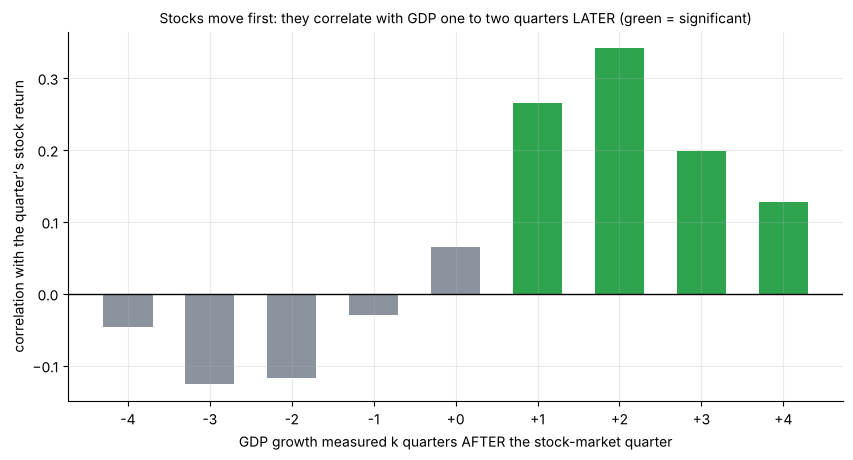

k        -4     -3     -2     -1    0     1     2     3     4 
corr -0.050 -0.130 -0.120 -0.030 0.070 0.270 0.340 0.200 0.130
t    -0.670 -2.060 -1.800 -0.390 0.800 3.640 4.360 2.520 2.070


In [2]:
L = st.lead_lag(panel, "g")
fig, ax = plt.subplots(figsize=(10, 4.8))
cols = [GOOD if t > 2 else GREY for t in L["t"]]
ax.bar(L.index, L["corr"], color=cols, width=0.6)
ax.axhline(0, color="k", lw=1)
ax.set_xticks(L.index)
ax.set_xticklabels([f"{k:+d}" for k in L.index])
ax.set_xlabel("GDP growth measured k quarters AFTER the stock-market quarter")
ax.set_ylabel("correlation with the quarter's stock return")
ax.set_title("Stocks move first: they correlate with GDP one to two quarters LATER "
             "(green = significant)", fontsize=10)
plt.show()
print(L[["corr", "t"]].round(2).T.to_string())

The tall green bars sit to the *right* of zero. The stock market's return this quarter lines up
with the economy's growth **one and two quarters later** — and barely at all with the quarter it
is living through. By the time GDP happens, the market has already moved.

### 4.2 What a perfect forecast is worth, by how far it sees

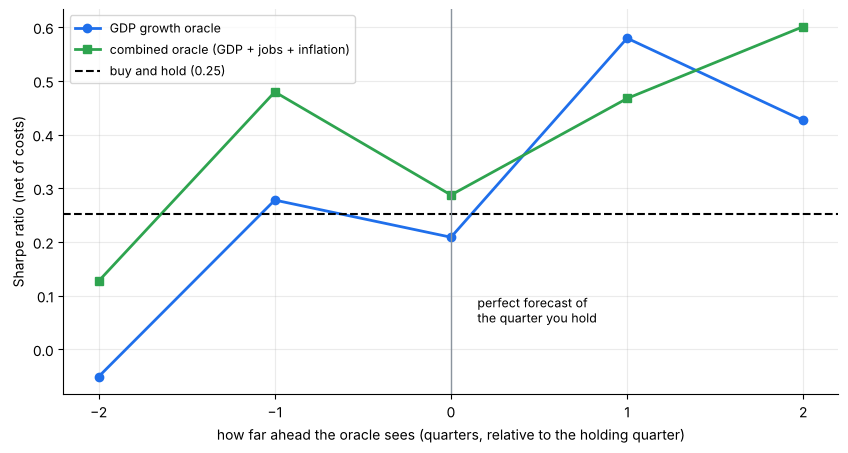

var  combined    dtb    du      g  infl
h                                      
-2      0.130  0.250 0.090 -0.050 0.300
-1      0.480  0.240 0.350  0.280 0.320
 0      0.290  0.250 0.240  0.210 0.350
 1      0.470  0.160 0.370  0.580 0.200
 2      0.600 -0.050 0.490  0.430 0.320


In [3]:
T, win = st.horizon_table(panel, n_boot=500, with_rotation=False)
sub = panel.loc[win]
bh = st.ann_sharpe(sub["ex"])
piv = T.pivot(index="h", columns="var", values="sharpe")
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(piv.index, piv["g"], "o-", lw=2, color=BLUE, label="GDP growth oracle")
ax.plot(piv.index, piv["combined"], "s-", lw=2, color=GOOD, label="combined oracle (GDP + jobs + inflation)")
ax.axhline(bh, color="k", ls="--", lw=1.5, label=f"buy and hold ({bh:.2f})")
ax.axvline(0, color=GREY, lw=1)
ax.annotate("perfect forecast of\nthe quarter you hold", (0, piv.loc[0, "g"]),
            xytext=(0.15, 0.05), fontsize=9)
ax.set_xticks(piv.index)
ax.set_xlabel("how far ahead the oracle sees (quarters, relative to the holding quarter)")
ax.set_ylabel("Sharpe ratio (net of costs)")
ax.legend(fontsize=9)
plt.show()
print(piv.round(2).to_string())

At h = 0 — a flawless forecast of the very quarter you are about to invest in — both oracles
sit on the buy-and-hold line (the combined one scores 0.29 against 0.25). Move
the crystal ball one quarter further out and the GDP oracle jumps to 0.58. The
economy you need to know about is not the one forecasters forecast; it is the one *after* it.

### 4.3 Growing a dollar

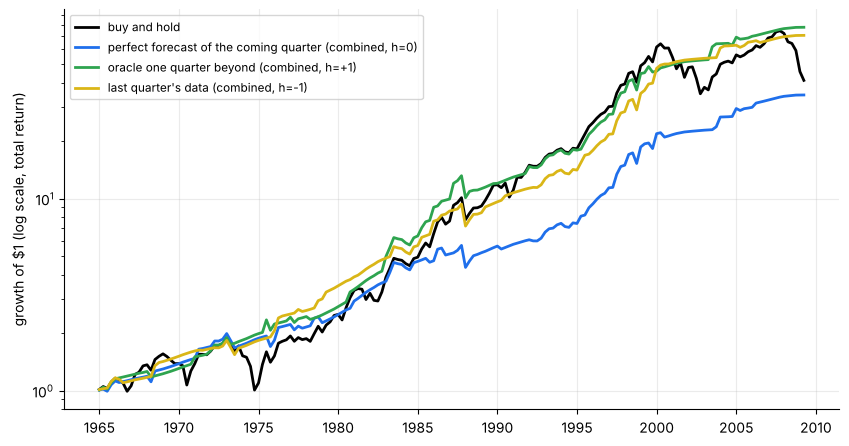

In [4]:
P = st.all_positions(panel).loc[win]
curves = {
    "buy and hold": sub["ex"] + sub["rf"],
    "perfect forecast of the coming quarter (combined, h=0)": st.book(P["combined@+0"], sub["ex"]) + sub["rf"],
    "oracle one quarter beyond (combined, h=+1)": st.book(P["combined@+1"], sub["ex"]) + sub["rf"],
    "last quarter's data (combined, h=-1)": st.book(P["combined@-1"], sub["ex"]) + sub["rf"],
}
colors = ["k", BLUE, GOOD, AMBER]
fig, ax = plt.subplots(figsize=(10, 5.2))
for (name, r), c in zip(curves.items(), colors):
    ax.plot((1 + r).cumprod(), lw=2, color=c, label=name)
ax.set_yscale("log")
ax.set_ylabel("growth of $1 (log scale, total return)")
ax.legend(fontsize=8.5)
plt.show()

> 🔬 **For the quants.** These are total-return wealth curves (dividends in, bills
> earned when out of the market). Over 45 years a Sharpe gap of 0.2 looks large on a log chart;
> whether it is distinguishable from luck is the bootstrap's job, in notebook 02.

### 4.4 The ceiling — what if the oracle knew the market itself?

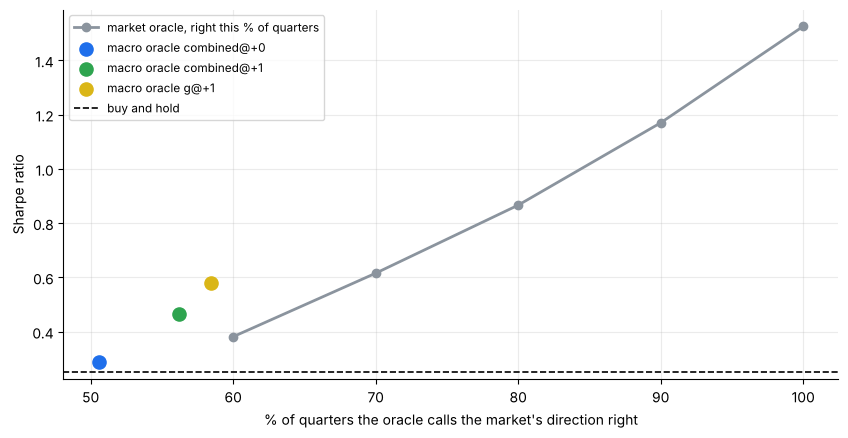

In [5]:
lad = st.ceiling_ladder(panel, win)
fig, ax = plt.subplots(figsize=(10, 4.8))
ax.plot(lad["hit_rate"] * 100, lad["sharpe"], "o-", color=GREY, lw=2,
        label="market oracle, right this % of quarters")
for name, c in (("combined@+0", BLUE), ("combined@+1", GOOD), ("g@+1", AMBER)):
    r = T[(T["var"] + "@" + T["h"].map(lambda x: f"{x:+d}")) == name].iloc[0]
    ax.scatter(r["hit_rate"] * 100, r["sharpe"], s=90, color=c, zorder=3,
               label=f"macro oracle {name}")
ax.axhline(bh, color="k", ls="--", lw=1.2, label="buy and hold")
ax.set_xlabel("% of quarters the oracle calls the market's direction right")
ax.set_ylabel("Sharpe ratio")
ax.legend(fontsize=8.5)
plt.show()

Knowing the market's own direction every quarter would have produced a Sharpe of
1.53. A perfect forecast of the coming quarter's economy captures about
3% of that gap — it calls the market's direction about as well as a coin.

## Beat 5 · The verdict

**Signal: None.** The claim as stated — a perfect forecast of the coming quarter's
economy tells you where stocks are going — fails: 0.29 against 0.25, inside
the range luck produces. The value only appears when the oracle sees beyond the quarter you
hold, and even there the combined oracle does not clear both luck tests.

**Tradability: Fragile.** The lagged rule a real investor could run looks good on paper
(0.48) but falls to 0.13 with one more quarter of delay, and it runs on
revised data that nobody actually had at the time.

**Stocks lead the economy? Confirmed.** Correlation with GDP growth is +0.07 in the same
quarter but +0.27 and +0.34 one and two quarters later.

> **In one sentence:** Even a flawless forecast of the coming quarter's GDP, jobs and inflation would have timed US stocks to a Sharpe of 0.29 against 0.25 for buying and holding, because the market had already moved on to pricing the quarter after — only an oracle that sees that far (0.47) starts to earn its fee; the lagged rule a real investor could run looks better on paper (0.48) but loses to buy-and-hold with one more quarter of lag (0.13).

## Beat 6 · Could you trade it?

Not as advertised. The only rule you could run with real information is the lagged one, and
three things undercut it: its edge disappears if the data arrive a quarter later; it was
measured on numbers revised years after the fact (real-time GDP is often off by a percentage
point or more); and its higher Sharpe comes from sitting out volatile quarters, not from extra
return. Costs are not the problem — it trades about once a year.

## Beat 7 · Going further 🚪

- **Real-time data.** Rerun the h = −1 leg on the Philadelphia Fed's real-time dataset
  (Croushore & Stark) — the as-first-published GDP numbers. Our guess: whatever is left shrinks.
- **The forecasters themselves.** Swap the oracle for the Survey of Professional Forecasters'
  consensus. If perfect foresight of the coming quarter is worth ~nothing, an imperfect one
  should be worth less.
- **Monthly.** Does knowing next month's payrolls perfectly do better than knowing next
  quarter's GDP? Neighbouring studies (payrolls day, GDPNow revisions) suggest the market prices
  even that within minutes.
- **The useful direction.** The market is a *forecaster* of the economy. That is the trade worth
  studying: stocks as a recession indicator, not the economy as a stock indicator.